# Conect Drive

In [ ]:
from google.colab import drive
drive.mount('./content')

Mounted at ./content


# Library

In [ ]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
from torch.utils.data import ConcatDataset
import matplotlib.pyplot as plt
from collections import deque
import numpy as np

# Load Images

In [ ]:
unlabel_train_path = '/content/content/MyDrive/MVTec/bottle/train/good'
unlabel_test_path = '/content/content/MyDrive/MVTec/bottle/test/good'
label_path = '/content/content/MyDrive/MVTec/bottle/test'
ground_truth_path = '/content/content/MyDrive/MVTec/bottle/ground_truth'

In [ ]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

In [ ]:
class ImageLoaderDataset(Dataset):
    def __init__(self, directory_path, transform=None, ignore_folders=None, subfolder=True, include_history=True,
                 include_loss_history=True, padding=True, padding_mode='constant', patch_size=64, crop_size=128, move_size=24, gray=False):
        """
        A custom Dataset class for loading images with optional padding and additional history/loss history layers.

        Parameters:
            directory_path (str): Path to the folder containing images.
            transform (callable, optional): A function/transform to apply to the images.
            ignore_folders (list, optional): Folders to ignore while loading images.
            subfolder (bool, optional): If True, load images from subfolders.
            include_history (bool, optional): If True, adds a binary history layer to each image.
            include_loss_history (bool, optional): If True, adds a loss history layer to each image.
            padding (bool, optional): Whether to add padding to the images.
            padding_mode (str, optional): The type of padding to apply (e.g., 'constant', 'reflect', etc.).
            patch_size (int): The size of the patches to be extracted.
            crop_size (int): The size of the crop/patch extracted initially.
            move_size (int): The size of the movement for the center of the patch.
        """
        self.directory_path = directory_path
        self.transform = transform if transform else transforms.ToTensor()
        self.ignore_folders = ignore_folders if ignore_folders else []
        self.subfolder = subfolder
        self.include_history = include_history
        self.include_loss_history = include_loss_history
        self.padding = padding
        self.padding_mode = padding_mode
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.move_size = move_size
        self.gray = gray
        self.image_paths = self._load_image_paths()

    def _load_image_paths(self):
        """
        Loads the paths of all images in the directory, including subfolders if specified.

        Returns:
            list: A list of paths to the image files.
        """
        image_paths = []
        if self.subfolder:
            subfolders = sorted(os.listdir(self.directory_path))
            subfolders = [sf for sf in subfolders if sf not in self.ignore_folders]
            print('Sorted Subfloders:')
            print(subfolders)
            for subfolder in subfolders:
                subfolder_path = os.path.join(self.directory_path, subfolder)
                if os.path.isdir(subfolder_path):
                    image_names = sorted(os.listdir(subfolder_path))
                    for img_name in image_names:
                        print(f'name image in subfolder {subfolder_path}')
                        print(img_name)
                        img_path = os.path.join(subfolder_path, img_name)
                        if img_path.endswith((".png", ".jpg", ".jpeg")):
                            image_paths.append(img_path)
        else:
            image_names = sorted(os.listdir(self.directory_path))
            for img_name in image_names:
                img_path = os.path.join(self.directory_path, img_name)
                if img_path.endswith((".png", ".jpg", ".jpeg")):
                    image_paths.append(img_path)
        return image_paths

    def __len__(self):
        """Returns the number of images in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Loads an image and applies the specified transformations.

        Parameters:
            idx (int): Index of the image to load.

        Returns:
            torch.Tensor: The transformed image tensor.
        """
        img_path = self.image_paths[idx]
        if self.gray:
          img = Image.open(img_path).convert("1") # Binary-Scale for Ground-Truths
        else:
          img = Image.open(img_path).convert("RGB") # RGB for Images
        img_tensor = self.transform(img)

        # Add binary history layer (initially all zeros) if enabled
        if self.include_history:
            history_layer = torch.zeros((1, img_tensor.size(1), img_tensor.size(2)))
            img_tensor = torch.cat([img_tensor, history_layer], dim=0)

        # Add loss history layer (initially all zeros) if enabled
        if self.include_loss_history:
            loss_history_layer = torch.zeros((1, img_tensor.size(1), img_tensor.size(2)))
            img_tensor = torch.cat([img_tensor, loss_history_layer], dim=0)

        # If padding is enabled, calculate and apply padding
        #if self.padding:
            # Calculate padding based on crop_size, move_size, and patch_size
            #remainder = self.crop_size // 2
            #c = remainder - self.move_size
            #calculated_padding = self.patch_size - c

            # Ensure padding is non-negative
            #calculated_padding = max(calculated_padding, 0)

            # Apply padding
            #padding = (calculated_padding, calculated_padding, calculated_padding, calculated_padding)  # (left, right, top, bottom)
            #img_tensor = F.pad(img_tensor, padding, mode=self.padding_mode, value=0)

        return img_tensor

In [ ]:
64 - ((128 // 2) - 24)

24

In [ ]:
unlabel_train = ImageLoaderDataset(directory_path=unlabel_train_path, transform=transform, subfolder=False)
unlabel_test = ImageLoaderDataset(directory_path=unlabel_test_path, transform=transform, subfolder=False)

In [ ]:
label_dataset = ImageLoaderDataset(directory_path=label_path, transform=transform, ignore_folders=['good'],
                                   subfolder=True)

Sorted Subfloders:
['.ipynb_checkpoints', 'broken_large', 'broken_small', 'contamination']
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
000.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
001.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
002.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
003.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
004.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
005.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
006.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
007.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
008.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/test/broken_large
009.png
name image in subfolder /cont

In [ ]:
ground_truth = ImageLoaderDataset(directory_path=ground_truth_path, transform=transform, subfolder=True,
                                  include_history=False, include_loss_history=False, gray=True)

Sorted Subfloders:
['.ipynb_checkpoints', 'broken_large', 'broken_small', 'contamination']
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
000_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
001_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
002_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
003_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
004_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
005_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
006_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
007_mask.png
name image in subfolder /content/content/MyDrive/MVTec/bottle/ground_truth/broken_large
008_mask.png


In [ ]:
print(f'num.of images unlabel train data: {len(unlabel_train)}')
print(f'num.of images unlabel test data: {len(unlabel_test)}')
print(f'num.of images label data: {len(label_dataset)}')
print(f'num.of ground-truth: {len(ground_truth)}')

num.of images unlabel train data: 209
num.of images unlabel test data: 20
num.of images label data: 63
num.of ground-truth: 63


In [ ]:
print(f'shape of images unlabel train data: {unlabel_train[0].shape}')
print(f'shape of images unlabel test data: {unlabel_test[0].shape}')
print(f'shape of images label data: {label_dataset[0].shape}')
print(f'shape of ground-truth: {ground_truth[0].shape}')

shape of images unlabel train data: torch.Size([5, 512, 512])
shape of images unlabel test data: torch.Size([5, 512, 512])
shape of images label data: torch.Size([5, 512, 512])
shape of ground-truth: torch.Size([1, 512, 512])


In [ ]:
torch.unique(ground_truth[0])

tensor([0., 1.])

In [ ]:
print(unlabel_train[0].min())
print(unlabel_train[0].max())

tensor(0.)
tensor(1.)


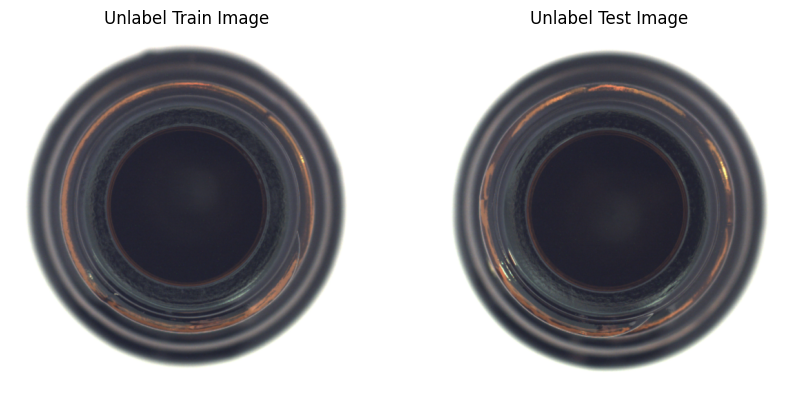

In [ ]:
# Select images and permute to change channel order
image1 = unlabel_train[0][:3].permute(1, 2, 0)  # Train image (RGB)
image2 = unlabel_test[0][:3].permute(1, 2, 0)   # Test image (RGB)

# Set up figure and subplot (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Create a figure with 2 subplots

# Display the first image
axes[0].imshow(image1)
axes[0].axis('off')  # Hide axis
axes[0].set_title('Unlabel Train Image')  # Set title for the first image

# Display the second image
axes[1].imshow(image2)
axes[1].axis('off')  # Hide axis
axes[1].set_title('Unlabel Test Image')  # Set title for the second image

# Show the figure
plt.show()

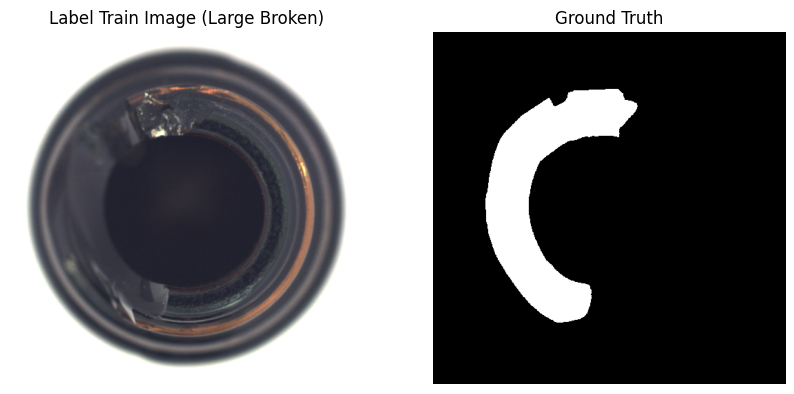

In [ ]:
image1 = label_dataset[10][:3].permute(1, 2, 0)  # Train image (RGB)
# Remove channel dimension to display as a grayscale image
label1 = ground_truth[10].squeeze(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image (RGB)
axes[0].imshow(image1)
axes[0].axis('off')  # Hide axis
axes[0].set_title('Label Train Image (Large Broken)')  # Set title for the first image

# Display the second image (grayscale)
axes[1].imshow(label1, cmap='gray')
axes[1].axis('off')  # Hide axis
axes[1].set_title('Ground Truth')  # Set title for the second image

# Show the figure
plt.show()

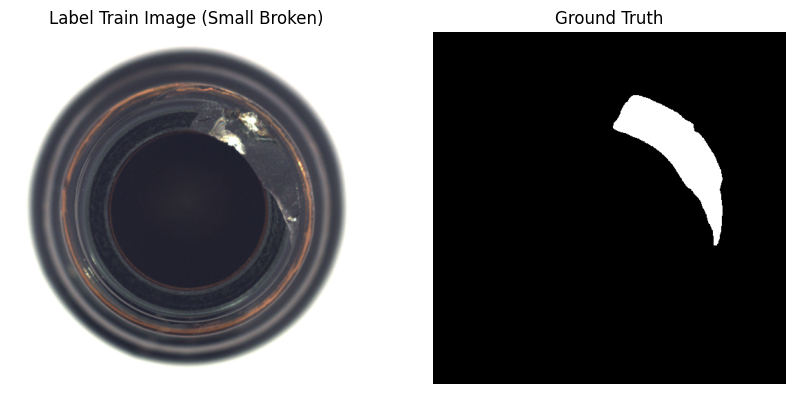

In [ ]:
image1 = label_dataset[30][:3].permute(1, 2, 0)  # Train image (RGB)
# Remove channel dimension to display as a grayscale image
label1 = ground_truth[30].squeeze(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image (RGB)
axes[0].imshow(image1)
axes[0].axis('off')  # Hide axis
axes[0].set_title('Label Train Image (Small Broken)')  # Set title for the first image

# Display the second image (grayscale)
axes[1].imshow(label1, cmap='gray')
axes[1].axis('off')  # Hide axis
axes[1].set_title('Ground Truth')  # Set title for the second image

# Show the figure
plt.show()

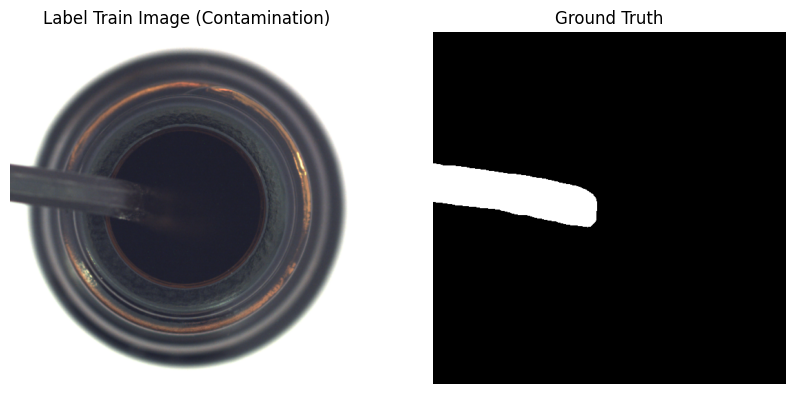

In [ ]:
image1 = label_dataset[55][:3].permute(1, 2, 0)  # Train image (RGB)
# Remove channel dimension to display as a grayscale image
label1 = ground_truth[55].squeeze(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image (RGB)
axes[0].imshow(image1)
axes[0].axis('off')  # Hide axis
axes[0].set_title('Label Train Image (Contamination)')  # Set title for the first image

# Display the second image (grayscale)
axes[1].imshow(label1, cmap='gray')
axes[1].axis('off')  # Hide axis
axes[1].set_title('Ground Truth')  # Set title for the second image

# Show the figure
plt.show()

In [ ]:
random.seed(42)

num_test_samples = 10
num_val_label_samples = 10
num_val_unlabel_samples = 9

label_indices = list(range(len(label_dataset)))
unlabel_indices = list(range(len(unlabel_train)))

test_label_indices = random.sample(label_indices, num_test_samples)
remaining_label_indices = list(set(label_indices) - set(test_label_indices))

val_label_indices = random.sample(remaining_label_indices, num_val_label_samples)
remaining_label_indices = list(set(remaining_label_indices) - set(val_label_indices))

val_unlabel_indices = random.sample(unlabel_indices, num_val_unlabel_samples)
remaining_unlabel_indices = list(set(unlabel_indices) - set(val_unlabel_indices))

In [ ]:
test_label_data = [label_dataset[i] for i in test_label_indices]
test_ground_truth = [ground_truth[i] for i in test_label_indices]

In [ ]:
val_label_data = [label_dataset[i] for i in val_label_indices]
val_ground_truth = [ground_truth[i] for i in val_label_indices]
val_unlabel_data = [unlabel_train[i] for i in val_unlabel_indices]

In [ ]:
train_label_data = [label_dataset[i] for i in remaining_label_indices]
train_ground_truth = [ground_truth[i] for i in remaining_label_indices]
train_unlabel_data = [unlabel_train[i] for i in remaining_unlabel_indices]

In [ ]:
default_ground_truth = torch.ones(1)

In [ ]:
train_data = list(zip(train_label_data, train_ground_truth)) + [(data, default_ground_truth) for data in train_unlabel_data]
val_data = list(zip(val_label_data, val_ground_truth)) + [(data, default_ground_truth) for data in val_unlabel_data]
test_data = list(zip(test_label_data, test_ground_truth)) + [(data, default_ground_truth) for data in unlabel_test]

In [ ]:
print(f'Number of training samples: {len(train_data)}')
print(f'Number of validation samples: {len(val_data)}')
print(f'Number of test samples: {len(test_data)}')

Number of training samples: 243
Number of validation samples: 19
Number of test samples: 30


In [ ]:
random.shuffle(train_data)
random.shuffle(val_data)
random.shuffle(test_data)

print(f'Number of training samples after shuffle: {len(train_data)}')
print(f'Number of validation samples after shuffle: {len(val_data)}')
print(f'Number of test samples after shuffle: {len(test_data)}')

Number of training samples after shuffle: 243
Number of validation samples after shuffle: 19
Number of test samples after shuffle: 30


In [ ]:
class ZippedDataset(Dataset):
    """
    A custom Dataset class for combining two datasets into one, returning a pair of data from each dataset.

    This class allows you to load data from two datasets simultaneously and retrieve corresponding pairs
    of data (e.g., images and their corresponding ground truth) by zipping the two datasets together.

    Parameters:
        dataset1 (Dataset): The first dataset (e.g., labeled images).
        dataset2 (Dataset): The second dataset (e.g., ground truth or another set of images).
    """
    def __init__(self, dataset1, dataset2):
        """
        Initializes the ZippedDataset with two datasets.

        Parameters:
            dataset1 (Dataset): The first dataset to combine.
            dataset2 (Dataset): The second dataset to combine.
        """
        self.dataset1 = dataset1  # Assign the first dataset
        self.dataset2 = dataset2  # Assign the second dataset

    def __len__(self):
        """
        Returns the length of the combined dataset. The length is determined by the smaller dataset
        to ensure we don't run out of data from either dataset.

        Returns:
            int: The number of items in the combined dataset, which is the minimum of the lengths of the two datasets.
        """
        return min(len(self.dataset1), len(self.dataset2))  # Return the minimum length between the two datasets

    def __getitem__(self, idx):
        """
        Retrieves a pair of data (e.g., an image from dataset1 and its corresponding item from dataset2)
        for the given index.

        Parameters:
            idx (int): The index to retrieve the data from both datasets.

        Returns:
            tuple: A tuple containing the data from both datasets. Typically, this is (data1, data2).
                Example: (image_from_dataset1, ground_truth_image_from_dataset2).
        """
        data1_image = self.dataset1[idx]  # Get the image (or data) from dataset1
        data2_image = self.dataset2[idx]  # Get the corresponding image (or data) from dataset2

        return data1_image, data2_image  # Return the pair of data


def combine_datasets(dataset1, dataset2):
    """
    Combine two datasets into a single dataset.

    Parameters:
        dataset1 (Dataset): The first dataset.
        dataset2 (Dataset): The second dataset.

    Returns:
        Dataset: A new dataset that combines the two input datasets.
    """
    # Combine the datasets using ConcatDataset
    combined_dataset = ConcatDataset([dataset1, dataset2])
    return combined_dataset

class UnlabeledDatasetWrapper(Dataset):
    """
    A wrapper for unlabeled datasets to add a None label for each data item.

    This class allows you to work with unlabeled datasets by adding a placeholder
    label (`None`) for compatibility with labeled datasets.
    """
    def __init__(self, dataset):
        """
        Initialize the wrapper with an unlabeled dataset.

        Parameters:
            dataset (Dataset): The original unlabeled dataset.
        """
        self.dataset = dataset

    def __len__(self):
        """
        Returns the number of items in the dataset.

        Returns:
            int: The length of the dataset.
        """
        return len(self.dataset)

    def __getitem__(self, idx):
        """
        Retrieve an item from the dataset and add a None label.

        Parameters:
            idx (int): The index of the item to retrieve.

        Returns:
            tuple: A tuple containing the data and a None label (data, None).
        """
        data = self.dataset[idx]
        return data, 1

In [ ]:
full_label_dataset = ZippedDataset(label_dataset, ground_truth)
unlabel_dataset = combine_datasets(unlabel_train, unlabel_test)

In [ ]:
print(f'num.of images full label data: {len(full_label_dataset)}')
print(f'num.of images pair full label data: {len(full_label_dataset[0])}')
print(f'shape of images label data: {full_label_dataset[0][0].shape}')
print(f'shape of images ground-truth: {full_label_dataset[0][1].shape}')
print(f'num.of images unlabel data: {len(unlabel_dataset)}')
print(f'shape of images unlabel train data: {unlabel_dataset[0].shape}')

num.of images full label data: 63
num.of images pair full label data: 2
shape of images label data: torch.Size([5, 512, 512])
shape of images ground-truth: torch.Size([5, 512, 512])
num.of images unlabel data: 229
shape of images unlabel train data: torch.Size([5, 512, 512])


In [ ]:
wrapped_unlabeled_dataset = UnlabeledDatasetWrapper(unlabel_dataset)

In [ ]:
print(f'num.of images unlabel data: {len(wrapped_unlabeled_dataset)}')
print(f'num.of iamges pair unlabel: {len(wrapped_unlabeled_dataset[0])}')
print(f'shape of images unlabel: {wrapped_unlabeled_dataset[0][0].shape}')
print(f'{wrapped_unlabeled_dataset[0][1]}')

num.of images unlabel data: 229
num.of iamges pair unlabel: 2
shape of images unlabel: torch.Size([5, 512, 512])
1


In [ ]:
final_dataset = combine_datasets(full_label_dataset, wrapped_unlabeled_dataset)

In [ ]:
print(f'{len(final_dataset)}')
print(f'{len(final_dataset[0])}')
print(f'{final_dataset[0][0].shape}')
print(f'{final_dataset[0][1].shape}')
print(f'{final_dataset[200][0].shape}')
print(f'{final_dataset[200][1]}')

292
2
torch.Size([5, 512, 512])
torch.Size([5, 512, 512])
torch.Size([5, 512, 512])
1


In [ ]:
dataloader = DataLoader(final_dataset, batch_size=1, shuffle=True)

# Neural Batch Sampler Class

In [ ]:
class NeuralBatchSampler(nn.Module):
    def __init__(self, input_size=900, crop_size=128, patch_size=64, move_size=24, action_space=9):
        """
        Initialize the NeuralBatchSampler class with necessary parameters.

        Parameters:
            input_size (int): The size of the input image (height/width).
            crop_size (int): The size of the crop/patch extracted from the image.
            patch_size (int): The size of the patches used in the network.
            move_size (int): The size by which the center of the patch is moved.
            action_space (int): The number of possible actions (directions).
        """
        super(NeuralBatchSampler, self).__init__()
        self.input_size = input_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.move_size = move_size
        self.action_space = action_space

        # Define convolutional layers for feature extraction
        self.conv1 = nn.Conv2d(5, 16, kernel_size=3, stride=2, padding=1)  # First convolution layer (5 input channels)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)

        # Fully connected layers for final classification/output
        self.fc1 = nn.Linear(64 * 4 * 4, 256)  # Linear layer after convolutional layers (flattened)
        self.fc2 = nn.Linear(256, action_space)  # Output layer with number of actions

        # Batch normalization layers to improve training stability
        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(32)
        self.bn4 = nn.BatchNorm2d(64)
        self.bn5 = nn.BatchNorm2d(64)

    def forward(self, patches):
        """
        Forward pass for the model, performing feature extraction and classification.

        Parameters:
            patches (Tensor): The image patches to be passed through the network.
            num_episode (int): The current episode number, used to change the input channels.

        Returns:
            Tensor: The predicted action probabilities from the network (softmax output).
        """
        # Forward pass through convolutional layers with ReLU activations and batch normalization
        #patches = patches.permute(0, 3, 1, 2) # Assume input might be (batch_size, height, width, channels)
        x = self.conv1(patches)
        x = F.relu(x)
        x = self.bn1(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.bn3(x)

        x = self.conv4(x)
        x = F.relu(x)
        x = self.bn4(x)

        x = self.conv5(x)
        x = F.relu(x)
        x = self.bn5(x)

        # Flatten the feature map and pass through fully connected layers
        x = torch.flatten(x, start_dim=1)
        #print("Flattened shape:", x.shape)
        x = F.relu(self.fc1(x))  # First fully connected layer with ReLU activation
        x = F.softmax(self.fc2(x), dim=1)  # Output layer with softmax activation to get action probabilities

        return x
    '''
    def select_crops(self, images, centers=None):
        """
        Select crops from the images based on the specified centers. If no centers are provided,
        they will be randomly generated within the valid range.

        Parameters:
            images (Tensor): The batch of input images from which patches will be extracted.
            centers (Tensor, optional): The center coordinates of the patches. If None, will be randomly generated.

        Returns:
            Tuple: A tuple containing:
                - patches (Tensor): The extracted image patches.
                - centers (Tensor): The center coordinates used for extracting the patches.
        """
        # Use no_grad since we don't need gradient computation here
        with torch.no_grad():
          batch_size, channels, _, _ = images.shape
          height, width = self.input_size, self.input_size
          # If no centers are provided, randomly generate them within valid bounds
          #if centers is None:
              #x_centers = torch.randint(self.crop_size // 2, height - self.crop_size // 2, (batch_size,))
              #y_centers = torch.randint(self.crop_size // 2, width - self.crop_size // 2, (batch_size,))
              #centers = torch.stack([x_centers, y_centers], dim=1)

          # Calculate the starting and ending coordinates for each patch
          x_starts = centers[:, 0] - self.crop_size // 2
          y_starts = centers[:, 1] - self.crop_size // 2
          x_ends = x_starts + self.crop_size
          y_ends = y_starts + self.crop_size


        crops = torch.zeros((batch_size, channels, self.crop_size, self.crop_size), device=images.device)
        for i in range(batch_size):
            # Ensure coordinates are within bounds
            x_start = max(0, x_starts[i])
            y_start = max(0, y_starts[i])
            x_end = min(width, x_ends[i])
            y_end = min(height, y_ends[i])

            crop = images[i, :, y_start:y_end, x_start:x_end]
            crops[i, :, :crop.shape[1], :crop.shape[2]] = crop
            del crop

        return crops, centers
    '''
    def select_crops(self, image, center=None):
      """
      Select a crop from the image based on the specified center. If no center is provided,
      it will be randomly generated within the valid range.

      Parameters:
          image (Tensor): The input image from which the patch will be extracted.
          center (Tensor, optional): The center coordinates of the patch. If None, will be randomly generated.

      Returns:
          Tuple: A tuple containing:
              - patch (Tensor): The extracted image patch.
              - center (Tensor): The center coordinates used for extracting the patch.
      """
      # Use no_grad since we don't need gradient computation here
      with torch.no_grad():
          batch_size, channels, _, _ = image.shape
          height, width = self.input_size, self.input_size
          '''
          if center is None:
              # If no center is provided, randomly generate one within valid bounds
              center_x = torch.randint(self.crop_size // 2, width - self.crop_size // 2, (1,))
              center_y = torch.randint(self.crop_size // 2, height - self.crop_size // 2, (1,))
              center = torch.stack([center_x, center_y], dim=0)
          '''
          # Calculate the starting and ending coordinates for the crop
          x_start = int(center[0].item()) - self.crop_size // 2
          y_start = int(center[1].item()) - self.crop_size // 2
          x_end = x_start + self.crop_size
          y_end = y_start + self.crop_size

          '''
          # Ensure coordinates are within bounds
          x_start = max(0, x_start.item())
          y_start = max(0, y_start.item())
          x_end = min(width, x_end.item())
          y_end = min(height, y_end.item())
          '''

          # Extract the patch from the image
          patch = image[:, :, y_start:y_end, x_start:x_end]

          return patch, center

    '''
    def move_select_patches(self, centers, actions, images):
        """
        Move the selected patches based on the given actions. The patches are moved by a specified move size
        in the image and the history layer is updated accordingly.

        Parameters:
            centers (Tensor): The current centers of the patches.
            actions (Tensor): The actions specifying the movement direction for each patch.
            images (Tensor): The input batch of images.

        Returns:
            Tuple: A tuple containing:
              - move_mask (Tensor): A binary mask indicating which patches were moved (shape: [batch_size]).
              - rows (Tensor): Row indices used for extracting patches (shape: [num_moved_patches, patch_size]).
              - cols (Tensor): Column indices used for extracting patches (shape: [num_moved_patches, patch_size]).
              - patches (Tensor): The extracted image patches after movement (shape: [num_moved_patches, channels, patch_size, patch_size]).
        """
        # Use no_grad since we don't need gradient computation here
        with torch.no_grad():
          batch_size, channels, ـ, ـ = images.shape
          height, width = self.input_size, self.input_size
          """
          Define the movement directions (dx, dy) for the actions:
            Action 1: Move up-left    -> dx = , dy =
            Action 2: Move down-left  -> dx = -move_size, dy =
            Action 3: Move up-right   -> dx = +move_size, dy = 0
            Action 4: Move down-right -> dx = +move_size, dy = 0
            Action 5: Stay (no movement) -> dx = 0, dy = 0
            Action 6: Move left       -> dx = -move_size, dy = +move_size
            Action 7: Move right      -> dx = +move_size, dy = +move_size
            Action 8: Move down-left  -> dx = -move_size, dy = -move_size
            Action 9: Move down-right -> dx = +move_size, dy = -move_size
          """
          dx = torch.tensor([float('nan'), -self.move_size, self.move_size, 0, 0, -self.move_size, -self.move_size, self.move_size, self.move_size])
          dy = torch.tensor([float('nan'), 0, 0, -self.move_size, self.move_size, -self.move_size, self.move_size, -self.move_size, self.move_size])

          if not isinstance(actions, torch.Tensor):
              actions = torch.tensor(actions)

          actions = actions.long()
          # Create a mask for which patches will be moved (i.e., actions != 0)
          move_mask = actions != 0
          new_x = centers[:, 0].clone()
          new_x = new_x.float()
          new_y = centers[:, 1].clone()
          new_y = new_y.float()

          # Update the centers based on the actions
          new_x[move_mask] += dx[actions[move_mask]]
          new_y[move_mask] += dy[actions[move_mask]]

          # Clamp the new centers within the valid range
          new_x[~move_mask] = float('nan')
          new_y[~move_mask] = float('nan')
          new_x = new_x.clamp(0, self.input_size - 1)
          new_y = new_y.clamp(0, self.input_size - 1)

          # Stack the new x and y coordinates to form the new centers
          new_centers = torch.stack([new_x, new_y], dim=1)

          patches = []
          half_patch = self.patch_size // 2
          for i in range(batch_size):
            if not move_mask[i]:
              continue

            x_start = int(new_x[i].item()) - half_patch
            y_start = int(new_y[i].item()) - half_patch
            x_end = x_start + self.patch_size
            y_end = y_start + self.patch_size

            # Extract patch
            patch = images[i, :3, y_start:y_end, x_start:x_end]
            patches.append(patch)

            # Update the history layer
            images[i, 3, y_start:y_end, x_start:x_end] = 1

        # Convert patches to a tensor
        patches = torch.stack(patches) if patches else torch.empty(0, 3, self.patch_size, self.patch_size, device=images.device)
        return move_mask, new_centers, patches
    '''
    def move_select_patches(self, center, action, image):
      """
      Move the selected patch based on the given action. The patch is moved by a specified move size
      in the image and the history layer is updated accordingly.

      Parameters:
          center (Tensor): The current center of the patch (shape: [2]).
          action (int): A single action specifying the movement direction for the patch.
          image (Tensor): The input image (shape: [channels, height, width]).

      Returns:
          Tuple: A tuple containing:
            - move_mask (Tensor): A binary mask indicating if the patch was moved (scalar).
            - new_center (Tensor): The updated center of the patch (shape: [2]).
            - patch (Tensor): The extracted image patch after movement (shape: [channels, patch_size, patch_size]).
      """
      #with torch.no_grad():
      batch_size, channels, _, _ = image.shape
      height, width = self.input_size, self.input_size
      # Define the movement directions (dx, dy) for the actions
      dx = torch.tensor([float('nan'), -self.move_size, self.move_size, 0, 0, -self.move_size, -self.move_size, self.move_size, self.move_size])
      dy = torch.tensor([float('nan'), 0, 0, -self.move_size, self.move_size, -self.move_size, self.move_size, -self.move_size, self.move_size])

      # Clone the current center and convert to float
      new_x = center[0].clone().float()
      new_y = center[1].clone().float()

      new_x += dx[action]
      new_y += dy[action]
      # Clamp the new center within the valid range of the image
      new_x = torch.clamp(new_x, min=self.crop_size // 2, max=width - self.crop_size // 2)
      new_y = torch.clamp(new_y, min=self.crop_size // 2, max=height - self.crop_size // 2)


      # Stack the new x and y coordinates to form the new center
      new_center = torch.tensor([new_x, new_y])

      # Extract the patch based on the new center
      half_patch = self.patch_size // 2
      x_start = int(new_x) - half_patch
      y_start = int(new_y) - half_patch
      x_end = x_start + self.patch_size
      y_end = y_start + self.patch_size

      patch = image[:, :3, y_start:y_end, x_start:x_end]

      # Update the history layer
      image[:, 3, y_start:y_end, x_start:x_end] = 1  # Assuming history layer is the 4th channel

      return new_center, patch

    def initial_patches(self, images):
        """
        Randomly initialize patch centers and extract patches from the images.

        Parameters:
            images (Tensor): The input batch of images (shape: [batch_size, channels, height, width]).

        Returns:
            Tuple:
                - patches (Tensor): The extracted patches of shape [batch_size, channels, patch_size, patch_size].
                - centers (Tensor): The randomly selected centers of the patches (shape: [batch_size, 2]).
        """
        # Use no_grad since we don't need gradient computation here
        with torch.no_grad():
            batch_size, channels, height, width = images.shape

            # Generate random centers within valid bounds
            x_centers = torch.randint(self.crop_size // 2, width - self.crop_size // 2, (batch_size,), device=images.device)
            y_centers = torch.randint(self.crop_size // 2, height - self.crop_size // 2, (batch_size,), device=images.device)
            centers = torch.stack([x_centers, y_centers], dim=1)


            x_starts = centers[:, 0] - self.patch_size // 2
            y_starts = centers[:, 1] - self.patch_size // 2
            x_ends = x_starts + self.patch_size
            y_ends = y_starts + self.patch_size
            # Initialize tensor for patches
            patches = torch.zeros((batch_size, 3, self.patch_size, self.patch_size), device=images.device)

            # Extract patches based on the random centers
            for i in range(batch_size):
                # Extract the patch and assign it to the corresponding position
                patch = images[i, :3, y_starts[i]:y_ends[i], x_starts[i]:x_ends[i]]
                patches[i] = patch
                del patch

        return patches, centers

# AutoEncoder Class

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, K=200):
        """
        Autoencoder with 8 convolutional and 8 deconvolutional layers,
        including a shortcut connection for speeding up training.

        Parameters:
            K (int): Number of bottleneck channels.
        """
        super(Autoencoder, self).__init__()

        # Encoder
        self.conv1 = nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64, affine=False)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64, affine=False)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128, affine=False)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(128, affine=False)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.bn5 = nn.BatchNorm2d(256, affine=False)
        self.conv6 = nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128, affine=False)
        self.conv7 = nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.bn7 = nn.BatchNorm2d(64, affine=False)
        self.conv8 = nn.Conv2d(64, K, kernel_size=8, stride=1, padding=0)

        # Decoder
        self.deconv1 = nn.ConvTranspose2d(K, 64, kernel_size=8, stride=1, padding=0)
        self.bn8 = nn.BatchNorm2d(64, affine=False)
        self.deconv2 = nn.ConvTranspose2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn9 = nn.BatchNorm2d(128, affine=False)
        self.deconv3 = nn.ConvTranspose2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn10 = nn.BatchNorm2d(256, affine=False)
        self.deconv4 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.bn11 = nn.BatchNorm2d(256, affine=False)
        self.deconv5 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.bn12 = nn.BatchNorm2d(128, affine=False)
        self.deconv6 = nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1)
        self.bn13 = nn.BatchNorm2d(128, affine=False)
        self.deconv7 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.bn14 = nn.BatchNorm2d(64, affine=False)
        self.deconv8 = nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        """
        Forward pass for the autoencoder.

        Parameters:
            x (Tensor): Input image tensor.

        Returns:
            Tensor: Reconstructed image tensor.
        """

        # Ensure input dimensions are in (batch_size, channels, height, width)
        if x.shape[1] != 3:  # Assume input might be (batch_size, height, width, channels)
            x = x.permute(0, 3, 1, 2)

        # Encoder
        x1 = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        x2 = F.leaky_relu(self.bn2(self.conv2(x1)), negative_slope=0.2)
        x3 = F.leaky_relu(self.bn3(self.conv3(x2)), negative_slope=0.2)
        x4 = F.leaky_relu(self.bn4(self.conv4(x3)), negative_slope=0.2)
        x5 = F.leaky_relu(self.bn5(self.conv5(x4)), negative_slope=0.2)
        x6 = F.leaky_relu(self.bn6(self.conv6(x5)), negative_slope=0.2)
        x7 = F.leaky_relu(self.bn7(self.conv7(x6)), negative_slope=0.2)
        bottleneck = self.conv8(x7)

        # Decoder
        d1 = F.leaky_relu(self.bn8(self.deconv1(bottleneck)), 0.2)
        d2 = F.leaky_relu(self.bn9(self.deconv2(d1)), 0.2)
        d3 = F.leaky_relu(self.bn10(self.deconv3(d2)), 0.2)
        d3 = torch.cat((d3, x5), dim=1)  # Skip connection
        d4 = F.leaky_relu(self.bn11(self.deconv4(d3)), 0.2)
        d5 = F.leaky_relu(self.bn12(self.deconv5(d4)), 0.2)
        d6 = F.leaky_relu(self.bn13(self.deconv6(d5)), 0.2)
        d7 = F.leaky_relu(self.bn14(self.deconv7(d6)), 0.2)
        reconstructed = self.deconv8(d7)  # No activation here; you can subtract from input

        return reconstructed

    def update_loss_channel(self, indices, patches, reconstructed, images, centers, patch_size=64):
      """
      Compute the loss map for each patch and update the fifth channel (history) of the corresponding images.

      Parameters:
          indices (list): List of indices indicating which images each patch corresponds to.
          patches (Tensor): Tensor of image patches (shape: [num_patches, 3, patch_size, patch_size]).
          reconstructed (Tensor): Tensor of reconstructed image patches (same shape as `patches`).
          images (Tensor): Tensor of original images (shape: [num_images, channels, height, width]).
          centers (list of tuples): List of (x, y) center coordinates for each patch.
          patch_size (int): Size of the patch (assumed to be square).

      Returns:
          loss_map (Tensor): Tensor containing the per-pixel loss map for each patch (shape: [num_patches, patch_size, patch_size]).
      """
      # Ensure input dimensions are in (batch_size, channels, height, width)
      #if x.shape[1] != 3:  # Assume input might be (batch_size, height, width, channels)
          #x = x.permute(0, 3, 1, 2)
      # Compute the loss map for each patch
      loss_map = torch.mean((patches - reconstructed) ** 2, dim=1)  # Shape: [num_patches, patch_size, patch_size]

      half_patch = patch_size // 2

      # Loop through each patch and update the corresponding image
      for i, index in enumerate(indices):
          center_x, center_y = centers[i]  # Get the center for the current patch

          # Extract patch bounds
          x_start = int(center_x) - half_patch
          y_start = int(center_y) - half_patch
          x_end = x_start + patch_size
          y_end = y_start + patch_size

          # Update the fifth channel of the image at the specified index
          images[index][0][4, y_start:y_end, x_start:x_end] = loss_map[i]

# Predictor

In [ ]:
class Predictor(nn.Module):
    def __init__(self, input_channels=10):
        """
        Predictor for binary segmentation using dilated convolutions.

        Parameters:
            input_channels (int): Number of input channels (default: 10 for loss history).
        """
        super(Predictor, self).__init__()

        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1, dilation=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=2, dilation=2)
        self.bn2 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=4, dilation=4)
        self.bn3 = nn.BatchNorm2d(8)
        self.conv4 = nn.Conv2d(8, 4, kernel_size=3, stride=1, padding=8, dilation=8)
        self.bn4 = nn.BatchNorm2d(4)
        self.output = nn.Conv2d(4, 1, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        """
        Forward pass for the predictor.

        Parameters:
            x (Tensor): Input loss profile tensor.

        Returns:
            Tensor: Predicted binary mask (softmax output).
        """
        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), negative_slope=0.2)
        output = torch.sigmoid(self.output(x))  # Binary segmentation mask
        return output

# Difine Networks

In [ ]:
sampler = NeuralBatchSampler(input_size=512, crop_size=128, patch_size=64, move_size=24, action_space=9)

In [ ]:
autoencoder = Autoencoder(K=200)

In [ ]:
predictor = Predictor(input_channels=10)

# train loop

In [ ]:
#images, labels = zip(*[ (im, l) for im, l in final_dataset])

In [ ]:
num_images = len(val_data)
buffer_capacity = 10

In [ ]:
count = sum(1 for _, ground_truth in val_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1)
h_l = [deque(maxlen=buffer_capacity) for _ in range(count)]
y_l = [ground_truth for _, ground_truth in val_data if isinstance(ground_truth, torch.Tensor) and ground_truth.dim() != 1]
countt = len(val_data) - count
h_u = [deque(maxlen=buffer_capacity) for _ in range(countt)]

In [ ]:
print(len(y_l), y_l[9].size())

10 torch.Size([1, 512, 512])


In [ ]:
print(len(val_data), len(h_l), len(h_u))

19 10 9


In [ ]:
# create buffer with aigmented (h_l, y_l)

In [ ]:
minibatch_size = 10
j=0
lowest_loss = np.inf

In [ ]:
patches, centers, index = [], [], []
for i, (image, ground_truth) in enumerate(train_data):
  z = 0
  exist_flag = False
  while not exist_flag:
    if z == 0:
      patch, center = sampler.initial_patches(image.unsqueeze(0))
      center = center[0]
      patches.append(patch.squeeze(0))
      centers.append(center)
      index.append(i)
      z+=1
      #print(f'1 {i}')
    elif z != 0:
      #print(f'2 {i}')
      crop, center_crop = sampler.select_crops(image.unsqueeze(0), center)
      action_probs = sampler.forward(crop)
      action = torch.multinomial(action_probs, 1)
      if action == 0:
        #print('change state')
        #print(len(patches))
        exist_flag = True
      else:
        center, patch = sampler.move_select_patches(image=image.unsqueeze(0), action=int(action[0].item()), center=center_crop)
        patches.append(patch.squeeze(0))
        centers.append(center)
        index.append(i)
      if (len(patches) == minibatch_size) or (len(patches) == minibatch_size - 1):
        patches = torch.stack(patches)
        reconstructeds = autoencoder.forward(patches)
        #print(reconstructeds.size())
        # loss AE Backward
        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=train_data, centers=centers)
        patches = []
        #print(len(patches))
        centers = []
        index = []
        batch_size = 8
        dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
        autoencoder.eval()
        with torch.no_grad():
          for ind, (batch_images, batch_labels) in enumerate(dataloader):
            #print(batch_images.size())
            reconstructeds = autoencoder(batch_images[:, :3, :, :])
            error = torch.mean((batch_images[:, :3, :, :] - reconstructeds) ** 2, dim=1)
            #print(error.size())
            l, u = 0
            for s in range(len(batch_images)):
              if isinstance(batch_labels[s], torch.Tensor) and batch_labels[s].dim() != 1:
                h_l[l].append(error[s].item())
                l+=1
              elif isinstance(batch_labels[s], torch.Tensor) and batch_labels[s].dim() == 1:
                h_u[u].append(error[s].item())
                u+=1
        autoencoder.train()
        # if len deque 10
        # append B, Augmented (h_l, y_l)
        # sampling in B and normalization (h_l,  y_l)
        # train Predictor with (h_l,  y_l)
        # loss backward for Predictor

        # if j%k>M: calculate R_Pred and update NBS
        # if j%k==0: reinitialize autoencoder and h_l, h_u
        # if l_pred < lowest_loss: h_star <--- h_u and lowest_loss <--- l_pred
        # j += 1
        # update Beta

1 0
2 0
2 0
2 0
2 0
change state
4
1 1
2 1
2 1
2 1
2 1
2 1
2 1
2 1
2 1
2 1
2 1
torch.Size([15, 3, 64, 64])
0
2 1
2 1
2 1
2 1
2 1
2 1
2 1
change state
6
1 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
torch.Size([15, 3, 64, 64])
0
2 2
2 2
2 2
change state
2
1 3
2 3
2 3
2 3
2 3
2 3
2 3
2 3
2 3
2 3
change state
11
1 4
2 4
2 4
2 4
torch.Size([15, 3, 64, 64])
0
2 4
2 4
2 4
2 4
2 4
2 4
2 4
2 4
2 4
2 4
change state
9
1 5
2 5
2 5
2 5
2 5
2 5
torch.Size([15, 3, 64, 64])
0
2 5
2 5
2 5
2 5
change state
3
1 6
2 6
2 6
2 6
2 6
2 6
2 6
2 6
2 6
2 6
2 6
2 6
change state
14
1 7
2 7
change state
15
torch.Size([15, 3, 64, 64])
0
1 8
2 8
2 8
2 8
2 8
2 8
change state
5
1 9
2 9
change state
6
1 10
2 10
2 10
change state
8
1 11
2 11
2 11
2 11
2 11
2 11
2 11
torch.Size([15, 3, 64, 64])
0
2 11
2 11
2 11
change state
2
1 12
2 12
2 12
2 12
change state
5
1 13
2 13
2 13
change state
7
1 14
2 14
2 14
change state
9
1 15
2 15
2 15
2 15
2 15
2 15
torch.Size([15, 3, 64, 64])
0
2 15
2 15
2 15
2 15
2 15
change state
4
1 16
2 16
2 1

KeyboardInterrupt: 

In [ ]:
len(patches)

1860

In [ ]:
'''
#############
'''
patches = []
centers = []
index = []
for i in range(len(images)):
  z = 1
  while True:
    if z == 0:
      patch, center = sampler.initial_patches(images[i].unsqueeze(0))
      center = center[0]
      patches.append(patch.squeeze(0))
      centers.append(center)
      index.append(i)
    else:
      crop, center_crop = sampler.select_crops(images[i].unsqueeze(0), center)
      action_probs = sampler.forward(crop)
      action = torch.multinomial(action_probs, 1)
      if action == 0:
        action = torch.Tensor([[1]])
      center, patch = sampler.move_select_patches(image=images[i].unsqueeze(0), action=int(action[0].item()), center=center_crop)
      patches.append(patch.squeeze(0))
      centers.append(center)
      index.append(i)
      if len(patches) == minibatch_size:
        patches = torch.stack(patches)
        reconstructeds = autoencoder.forward(patches)
        # loss AE Backward
        autoencoder.update_loss_channel(indices=index, patches=patches, reconstructed=reconstructeds, images=images, centers=centers)
        patches = []
        centers = []
        data = list(zip(images, labels))
        batzh_size = 32
        dataloader = DataLoader(data, batch_size=batch_size, shuffle=False)
        autoencoder.eval()
        with torch.no_grad():
          for i, (batch_images, batch_labels) in enumerate(dataloader):
            #print(batch_images.size())
            reconstructeds = autoencoder(batch_images[:, :3, :, :])
            error = torch.mean((batch_images[:, :3, :, :] - reconstructeds) ** 2, dim=1)
            print(error.size())
            for j in range(len(batch_images)):
                if batch_labels[j] != 1:
                    buffers[j + (i * batch_size)].append(error[j].item())
                    # append label to buffer
        autoencoder.train()
        if
        if
        if

KeyboardInterrupt: 

In [ ]:
labels = [torch.tensor(label) if not isinstance(label, torch.Tensor) else label for label in labels]
data = list(zip(images, labels))
autoencoder.eval()
j = 0
with torch.no_grad():
  for i, (image, label) in enumerate(data):
    #print(batch_images.size())
    reconstructeds = autoencoder(image[:3, :, :].unsqueeze(0))
    error = torch.mean((image[:3, :, :].unsqueeze(0) - reconstructeds) ** 2, dim=1)
    print(error.size())
    if isinstance(label, torch.Tensor):
      if label.dim() != 0:
        buffers[j].append(error.squeeze(0))
        j+=1

torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 512, 512])


KeyboardInterrupt: 

In [ ]:
buffer_capacity = 10
buffers = [deque(maxlen=buffer_capacity) for _ in range(63)]

In [ ]:
tensor_size = (512, 512)

In [ ]:
a=torch.stack(list(buffers[15]))

In [ ]:
a[7]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
buffers[0]

deque([])

In [ ]:
buffers[1]

deque([])

In [ ]:
images[1][4].sum()

tensor(0.)

In [ ]:
reconstructeds

torch.Size([10, 64, 64])

In [ ]:
print(type(reconstructeds))
print(reconstructeds[0].size())

<class 'torch.Tensor'>
torch.Size([3, 64, 64])


In [ ]:
print(type(patches))
print(patches[0].size())

<class 'torch.Tensor'>
torch.Size([3, 64, 64])


In [ ]:
images[0][3].sum()

tensor(168317.)

In [ ]:
reconstructeds[0].size()

torch.Size([3, 64, 64])

In [ ]:
patches_tensor = torch.stack(patches)
print(patches_tensor.size())

torch.Size([1594, 3, 64, 64])


In [ ]:
patches_tensor.size()

torch.Size([1594, 3, 64, 64])

In [ ]:
a = autoencoder.forward(patches_tensor[:10])

In [ ]:
a.size()

torch.Size([10, 3, 64, 64])

In [ ]:
print(len(patches), len(centers), len(index))

1055 1055 1055


In [ ]:
print(centers[1000], index[1000])

tensor([280., 740.]) 0


In [ ]:
print(patches[1000].size())

torch.Size([1, 3, 64, 64])


In [ ]:
torch.Tensor([-24.]).size() == torch

False

# Learn Loop

In [ ]:
for batch_idx, (images, ground_truths) in enumerate(labeldataloader):
    print(f"Processing batch {batch_idx + 1} from labeled DataLoader...")

    # Select crops and their centers
    crops, centers = sampler.select_crops(images)
    print(len(crops))
    print(crops[0].shape)

    # Forward pass through the sampler to get actions
    actions = sampler.forward(crops, num_episode=2)
    print(len(actions))
    print(actions[0].shape)
    print(actions[0])

    # Choose actions (argmax for the highest probability)
    chosen_actions = torch.argmax(actions, dim=1)
    print(len(chosen_actions))
    print(chosen_actions)

    # Move selected patches based on actions
    move_mask, rows, cols, patches = sampler.move_select_patches(centers, chosen_actions, images)
    print(len(move_mask))
    print(move_mask)
    print(sum(move_mask))
    print(len(rows), len(cols))
    print(len(patches))
    print(patches[0].shape)

    # Process patches with Autoencoder
    reconstructed_patches = autoencoder(patches)
    print(len(reconstructed_patches))
    print(reconstructed_patches[0].shape)

    # Compute loss and update the history layer
    loss_map = autoencoder.compute_loss_and_update(
        x=patches,
        reconstructed=reconstructed_patches,
        images=images,
        move_mask=move_mask,
        rows=rows,
        cols=cols
    )

    # Print loss map shape
    print("Loss map shape:", loss_map.shape)

    break

Processing batch 1 from labeled DataLoader...
32
torch.Size([128, 128, 5])
Flattened shape: torch.Size([32, 1024])
32
torch.Size([9])
tensor([0.0897, 0.1172, 0.1541, 0.0937, 0.1014, 0.1139, 0.0888, 0.1553, 0.0858],
       grad_fn=<SelectBackward0>)
32
tensor([7, 2, 0, 2, 8, 3, 7, 7, 2, 0, 6, 2, 7, 0, 3, 7, 0, 3, 2, 0, 7, 0, 0, 7,
        0, 7, 0, 0, 7, 7, 0, 7])
32
tensor([ True,  True, False,  True,  True,  True,  True,  True,  True, False,
         True,  True,  True, False,  True,  True, False,  True,  True, False,
         True, False, False,  True, False,  True, False, False,  True,  True,
        False,  True])
tensor(21)
21 21
21
torch.Size([64, 64, 3])
21
torch.Size([3, 64, 64])
سلام
21
torch.Size([64, 64])
21
torch.Size([21, 21, 64, 64])
Loss map shape: torch.Size([21, 64, 64])


In [ ]:
rows.unsqueeze(-1).shape
cols.unsqueeze(1).shape

torch.Size([30, 1, 64])

In [ ]:
for batch_idx, images in enumerate(unlabel_dataloader):
    print(f"Processing batch {batch_idx + 1} from unlabeled DataLoader...")
    # Select initial crops
    crops, centers = sampler.select_crops(images)

    # Forward pass to predict actions
    actions = sampler.forward(crops, num_episode=1)

    # Select the action with the highest probability for each patch
    chosen_actions = torch.argmax(actions, dim=1)

    # Move and select patches based on the chosen actions
    new_centers, move_mask, new_patches = sampler.move_select_patches(centers, chosen_actions, images)

    print(f"New centers shape: {new_centers.shape}")
    print(f"Move mask: {move_mask}")
    print(f"New patches shape: {new_patches.shape}")
    break  # Remove this break to process all batches


In [ ]:
images.shape

torch.Size([32, 5, 948, 948])

In [ ]:
images[0, 3, 0:63, 63:65].shape

torch.Size([63, 2])